# Crypto Funding Deployment Loop

**Book Reference**: Chapter 25, Section 25.6 (Ensuring technical parity through pipeline
verification)

**Requires**: the `live` optional dependency group (`uv sync --extra live`), which supplies
`python-okx` for the data plane and `alpaca-py` for the execution plane.

This notebook is the chapter's crypto deployment-loop demonstration. The
*Chapter 12* funding-rate case study trains on Binance-derived perpetuals;
this notebook re-enacts the deployment cycle for that strategy across two
distinct venues: OKX provides the live data plane (OHLCV bars and 8-hour
funding rates for the currently available subset of the 19-perp research
universe), and Alpaca paper trading provides the execution plane on the
subset of symbols Alpaca lists as USD-quoted spot crypto. The cycle has six
steps:

1. **Connect** to the OKX public API (data) and Alpaca paper account (execution).
2. **Train** a LightGBM 3-class direction model on the historical
   Binance-derived 8-hour panel using the same 13-feature schema the live
   pipeline computes.
3. **Persist** the deployment artefacts separately from the case-study
   research registry.
4. **Predict** the latest cross-section by fetching live OKX bars and funding,
   computing features, and scoring every currently available perp.
5. **Trade** the resulting basket via Alpaca paper crypto on the eleven
   USD-quoted spot pairs Alpaca lists; log the remaining perps as
   signal-only.
6. **Persist** the run as a JSON record for monitoring and audit.

**Venue split** (Binance research → OKX live data → Alpaca execution) and
the eight-name coverage gap on USD-quoted spot pairs: see §25.3 and §25.6
for the rationale.

**Important framing.** This notebook is a deployment-engineering rehearsal,
not investment advice. Paper trading on Alpaca exercises the real broker
session under real account credentials; it does not commit capital. The
notebook is structured to teach the operational mechanics of the deployment
loop. It is not a recommendation to trade real money on this strategy.

**Cross-References**
- Chapter 12: Funding-rate case study (model training and registry)
- Chapter 7: Triple-barrier and direction labels
- Chapter 25.3: Integrating with Alpaca
- Chapter 25.6: Ensuring technical parity through pipeline verification
- Chapter 26: Repeated model serving and monitoring

**Learning Objectives**
- Run a real retrain-and-deploy cycle on the funding-rate strategy with no
  mock components.
- Separate the data-plane venue (OKX) from the execution-plane venue
  (Alpaca paper) and reason about each independently.
- Surface the coverage cost of a research universe that does not align with
  live execution capabilities.

**Prerequisites**
- OKX public API reachable (no key required for OHLCV and funding endpoints).
- Alpaca paper credentials are needed only for an operator-authorized run
  with `SUBMIT_PAPER_ORDERS=True`; the publication run is dry-run.
- Historical 8-hour perp data under `ML4T_DATA_PATH/crypto_perps` and
  premium index data under `ML4T_DATA_PATH/crypto_premium`.
- Direction-label parquet at
  `case_studies/crypto_perps_funding/labels/fwd_dir_8h_3c.parquet`.

In [1]:
"""Crypto Funding Deployment Loop: refresh, refit, predict, paper-trade, persist."""

import hashlib
import json
import logging
import os
import pickle
import sys
import warnings
from datetime import UTC, datetime, timedelta
from pathlib import Path

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r"\s*Use of plotly\.io\.kaleido\.scope\..*",
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    message=r"\s*websockets\.legacy is deprecated.*",
)

import lightgbm as lgb
import numpy as np
import plotly.graph_objects as go
import polars as pl
from async_utils import run_async
from sklearn.preprocessing import StandardScaler

from data import load_crypto_perps, load_crypto_premium
from utils.paths import display_path, get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    stream=sys.stdout,
)
logger = logging.getLogger("crypto_funding_deployment")
logging.getLogger("ml4t").setLevel(logging.WARNING)

In [2]:
TRAIN_END_DATE = "2024-12-31"  # historical training cut
NUM_BOOST_ROUND = 200
LEARNING_RATE = 0.05
NUM_LEAVES = 31
NUM_THREADS = 4
SEED = 42
TRAIN_DEVICE = "cpu"  # deterministic CPU training; a reader reproduces the artifact bit for bit
PROB_LONG_THRESHOLD = (
    0.30  # any non-trivial probability mass on P(up); soft for demo (production: ≥0.45)
)
PROB_SHORT_THRESHOLD = (
    0.30  # any non-trivial probability mass on P(down); soft for demo (production: ≥0.45)
)
NOTIONAL_PER_LEG_USD = 100.0  # paper notional per symbol
SUBMIT_PAPER_ORDERS = False  # explicit opt-in only; publication execution is dry-run
MIN_OKX_LIVE_COVERAGE = 0.75

## 1. Setup and Venue Connections

Two venues, each with a distinct role. The notebook fails loudly if either
is unreachable rather than degrading silently. A deployment loop that hides
its failure modes teaches the wrong lesson.

In [3]:
CHAPTER_DIR = get_chapter_dir(25)
CASE_STUDIES_ROOT = Path(os.environ.get("CASE_STUDIES_DIR", CHAPTER_DIR.parent / "case_studies"))
ARTIFACTS_DIR = get_output_dir(25, "crypto_funding_deployment")
RUNS_DIR = ARTIFACTS_DIR / "runs"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

The requested deployment universe is fixed to the nineteen perpetuals used
by the research case study. The live venue may retire an instrument, so the
cycle records and gates the available subset instead of silently changing the
research universe.

In [4]:
CASE_STUDY_UNIVERSE = [
    "AAVEUSDT",
    "ADAUSDT",
    "APTUSDT",
    "ATOMUSDT",
    "AVAXUSDT",
    "BNBUSDT",
    "BTCUSDT",
    "COMPUSDT",
    "DOGEUSDT",
    "DOTUSDT",
    "ETHUSDT",
    "INJUSDT",
    "LINKUSDT",
    "MKRUSDT",
    "NEARUSDT",
    "SOLUSDT",
    "SUIUSDT",
    "UNIUSDT",
    "XRPUSDT",
]

# Mapping from case-study perp symbol to OKX instrument ID
OKX_INSTRUMENT = {sym: f"{sym[:-4]}-USDT-SWAP" for sym in CASE_STUDY_UNIVERSE}

The demo carries an explicit eleven-pair mapping for its paper-execution rehearsal.

The mapping is written out rather than queried, and both halves of that choice matter. USD
pairs rather than USDT ones, because the paper account is funded in USD and a quote-currency
mismatch is a different instrument. And a fixed list rather than a live catalogue lookup,
because a venue's listings change and a notebook that silently tracked them would produce a
different universe on every run with nothing recording which one it used.

The cost is that the list goes stale, which is the right cost to pay here: a stale mapping
fails visibly against a symbol the venue no longer lists, where a silent one changes the
strategy underneath the reader.

In [5]:
ALPACA_USD_PAIR = {
    "AAVEUSDT": "AAVE/USD",
    "ADAUSDT": "ADA/USD",
    "AVAXUSDT": "AVAX/USD",
    "BTCUSDT": "BTC/USD",
    "DOGEUSDT": "DOGE/USD",
    "DOTUSDT": "DOT/USD",
    "ETHUSDT": "ETH/USD",
    "LINKUSDT": "LINK/USD",
    "SOLUSDT": "SOL/USD",
    "UNIUSDT": "UNI/USD",
    "XRPUSDT": "XRP/USD",
}

The serialized feature order is also the model input contract.

In [6]:
FEATURE_COLS = [
    "premium_zscore",
    "premium_change_1bar",
    "premium_change_3bar",
    "ret_1bar",
    "ret_3bar",
    "ret_21bar",
    "vol_3bar",
    "vol_21bar",
    "vol_ratio_3bar",
    "rsi_14",
    "dist_vwap_3bar",
    "premium_level",
    "funding_zscore_21bar",
]

The startup banner exposes the research, data, execution, artifact, and mutation boundaries.

In [7]:
print("=" * 70)
print("CRYPTO FUNDING DEPLOYMENT LOOP")
print("=" * 70)
print(f"Strategy universe: {len(CASE_STUDY_UNIVERSE)} perps (Binance-style USDT-quoted)")
print(
    f"  Data plane:      OKX public API "
    f"(requesting {len(CASE_STUDY_UNIVERSE)} *-USDT-SWAP instruments)"
)
print(
    f"  Execution plane: Alpaca paper crypto on USD pairs "
    f"({len(ALPACA_USD_PAIR)}/{len(CASE_STUDY_UNIVERSE)} symbols)"
)
unmatched = sorted(set(CASE_STUDY_UNIVERSE) - set(ALPACA_USD_PAIR))
print(f"  Signal-only:     {len(unmatched)} perps with no Alpaca USD listing")
print(f"                   {', '.join(unmatched)}")
print(f"Artifacts dir:     {display_path(ARTIFACTS_DIR)}")
print(f"Order submission:  {'ENABLED' if SUBMIT_PAPER_ORDERS else 'DISABLED (dry-run)'}")

set_global_seeds(SEED)

CRYPTO FUNDING DEPLOYMENT LOOP
Strategy universe: 19 perps (Binance-style USDT-quoted)
  Data plane:      OKX public API (requesting 19 *-USDT-SWAP instruments)
  Execution plane: Alpaca paper crypto on USD pairs (11/19 symbols)
  Signal-only:     8 perps with no Alpaca USD listing
                   APTUSDT, ATOMUSDT, BNBUSDT, COMPUSDT, INJUSDT, MKRUSDT, NEARUSDT, SUIUSDT
Artifacts dir:     25_live_trading/output/crypto_funding_deployment
Order submission:  DISABLED (dry-run)


Eight of the nineteen case-study perps are absent from the
demo's fixed Alpaca mapping. The strategy was researched on a universe chosen
for funding-data depth, while the execution rehearsal uses a narrower spot
universe. That declared gap illustrates the research/deployment alignment
cost discussed in §25.6 without claiming a current exhaustive venue catalogue.

### 1a. OKX Data Plane

OKX is the live data source for funding rates and OHLCV bars. The notebook
uses public REST endpoints; no OKX API key is required. If the OKX SDK is
missing or the API is unreachable, the notebook stops here rather than
falling back to historical data. The live cross-section is the whole point
of the predict step.

In [8]:
try:
    import okx.MarketData as MarketData
    import okx.PublicData as PublicData
except ImportError as e:
    raise RuntimeError(
        "OKX SDK is required for the data plane. Install with: uv pip install python-okx"
    ) from e

market_api = MarketData.MarketAPI(flag="0")  # 0 = live
public_api = PublicData.PublicAPI(flag="0")
OKX_CANDLE_AUDIT: list[dict] = []
OKX_FUNDING_AUDIT: list[dict] = []

#### Fetch 1H OHLCV bars

OKX's v5 API supports `1H`, `4H`, and `1D` candles for the SWAP product but
not `8H`. We pull hourly bars and aggregate downstream so the live cadence
matches the strategy's 8-hour funding-aligned decision schedule.

In [9]:
def audit_okx_candle_payload(inst_id: str, rows: list[list[str]]) -> dict:
    """Summarize one raw OKX candle payload before parsing."""
    well_formed = [row for row in rows if len(row) > 8]
    confirmed = [row for row in well_formed if row[8] == "1"]
    timestamps = [row[0] for row in confirmed]
    payload = json.dumps(rows, separators=(",", ":"), sort_keys=True).encode()
    return {
        "instrument": inst_id,
        "payload_sha256": hashlib.sha256(payload).hexdigest(),
        "raw_rows": len(rows),
        "malformed_rows": len(rows) - len(well_formed),
        "unconfirmed_rows": len(well_formed) - len(confirmed),
        "confirmed_rows": len(confirmed),
        "duplicate_confirmed_timestamps": len(timestamps) - len(set(timestamps)),
    }

The parser records raw conservation counts and a payload hash before converting confirmed candles.

In [10]:
def fetch_okx_candles_1h(inst_id: str, limit: int = 300) -> pl.DataFrame:
    """Fetch 1H OHLCV bars for an OKX perpetual swap. `limit` capped at 300."""
    result = market_api.get_candlesticks(instId=inst_id, bar="1H", limit=str(min(limit, 300)))
    if result.get("code") != "0":
        raise RuntimeError(f"OKX candles error for {inst_id}: {result}")
    rows = result["data"]
    audit = audit_okx_candle_payload(inst_id, rows)
    confirmed_rows = [row for row in rows if len(row) > 8 and row[8] == "1"]
    if not confirmed_rows:
        audit["parsed_rows"] = 0
        OKX_CANDLE_AUDIT.append(audit)
        return pl.DataFrame(
            schema={
                "timestamp": pl.Datetime("ms", "UTC"),
                "open": pl.Float64,
                "high": pl.Float64,
                "low": pl.Float64,
                "close": pl.Float64,
                "volume": pl.Float64,
            }
        )
    df = pl.DataFrame(
        {
            "timestamp": [int(r[0]) for r in confirmed_rows],
            "open": [float(r[1]) for r in confirmed_rows],
            "high": [float(r[2]) for r in confirmed_rows],
            "low": [float(r[3]) for r in confirmed_rows],
            "close": [float(r[4]) for r in confirmed_rows],
            "volume": [float(r[5]) for r in confirmed_rows],
        }
    )
    parsed = df.with_columns(
        pl.col("timestamp").cast(pl.Datetime("ms")).dt.replace_time_zone("UTC")
    ).sort("timestamp")
    audit["parsed_rows"] = len(parsed)
    OKX_CANDLE_AUDIT.append(audit)
    return parsed

#### Aggregate 1H bars to 8H windows

The window label is the *start* of the 8-hour interval, matching the
case-study panel convention where each row's timestamp is the funding
settlement at which the strategy makes a decision.

In [11]:
def aggregate_to_8h(bars_1h: pl.DataFrame) -> pl.DataFrame:
    """Aggregate 1H OHLCV bars into 8H windows aligned with UTC 00/08/16."""
    if len(bars_1h) == 0:
        return bars_1h
    return (
        bars_1h.sort("timestamp")
        .group_by_dynamic("timestamp", every="8h", period="8h", closed="left")
        .agg(
            [
                pl.col("open").first().alias("open"),
                pl.col("high").max().alias("high"),
                pl.col("low").min().alias("low"),
                pl.col("close").last().alias("close"),
                pl.col("volume").sum().alias("volume"),
                pl.len().alias("_n_hours"),
            ]
        )
        .filter(pl.col("_n_hours") == 8)
        .drop("_n_hours")
    )

#### Fetch funding-rate history

Realized funding rates are published every 8 hours on OKX. The notebook
joins the most recent funding rate to each 8H bar via a backward as-of
join when the live panel is built in §4.

In [12]:
def audit_okx_funding_payload(inst_id: str, rows: list[dict]) -> dict:
    """Summarize one raw OKX funding payload before parsing."""
    well_formed = [
        row
        for row in rows
        if row.get("fundingTime") is not None and row.get("fundingRate") is not None
    ]
    timestamps = [row["fundingTime"] for row in well_formed]
    payload = json.dumps(rows, separators=(",", ":"), sort_keys=True).encode()
    return {
        "instrument": inst_id,
        "payload_sha256": hashlib.sha256(payload).hexdigest(),
        "raw_rows": len(rows),
        "malformed_rows": len(rows) - len(well_formed),
        "parsed_rows": len(well_formed),
        "duplicate_timestamps": len(timestamps) - len(set(timestamps)),
    }

The funding parser applies the same raw-payload identity and conservation boundary as the candle parser.

In [13]:
def fetch_okx_funding_history(inst_id: str, limit: int = 100) -> pl.DataFrame:
    """Fetch realized funding-rate history for a single OKX perpetual swap."""
    result = public_api.funding_rate_history(instId=inst_id, limit=str(limit))
    if result.get("code") != "0":
        raise RuntimeError(f"OKX funding history error for {inst_id}: {result}")
    rows = result["data"]
    audit = audit_okx_funding_payload(inst_id, rows)
    OKX_FUNDING_AUDIT.append(audit)
    parsed_rows = [
        row
        for row in rows
        if row.get("fundingTime") is not None and row.get("fundingRate") is not None
    ]
    if not parsed_rows:
        return pl.DataFrame(
            schema={
                "timestamp": pl.Datetime("ms", "UTC"),
                "funding_rate": pl.Float64,
            }
        )
    df = pl.DataFrame(
        {
            "timestamp": [int(row["fundingTime"]) for row in parsed_rows],
            "funding_rate": [float(row["fundingRate"]) for row in parsed_rows],
        }
    )
    return df.with_columns(
        pl.col("timestamp").cast(pl.Datetime("ms")).dt.replace_time_zone("UTC")
    ).sort("timestamp")

A single-symbol connectivity probe fails early before the full cross-section begins.

In [14]:
# OKX connectivity check on a single symbol
print("\nOKX connectivity check on BTC-USDT-SWAP ...")
test_1h = fetch_okx_candles_1h("BTC-USDT-SWAP", limit=24)
test_8h = aggregate_to_8h(test_1h)
test_funding = fetch_okx_funding_history("BTC-USDT-SWAP", limit=5)
print(f"  1H candles: {len(test_1h)} bars; aggregated to {len(test_8h)} 8H bars")
print(f"  latest 8H close = ${test_8h['close'][-1]:,.2f} at {test_8h['timestamp'][-1]}")
print(
    f"  funding:    {len(test_funding)} entries; latest funding = "
    f"{test_funding['funding_rate'][-1]:.4%}"
)
OKX_CANDLE_AUDIT.clear()
OKX_FUNDING_AUDIT.clear()


OKX connectivity check on BTC-USDT-SWAP ...


2026-09-08 21:27:44,914 INFO HTTP Request: GET https://www.okx.com/api/v5/market/candles?instId=BTC-USDT-SWAP&bar=1H&limit=24 "HTTP/2 200 OK"


2026-09-08 21:27:45,140 INFO HTTP Request: GET https://www.okx.com/api/v5/public/funding-rate-history?instId=BTC-USDT-SWAP&limit=5 "HTTP/2 200 OK"


  1H candles: 23 bars; aggregated to 2 8H bars
  latest 8H close = $78,420.70 at 2026-09-08 16:00:00+00:00
  funding:    5 entries; latest funding = 0.0048%


### 1b. Alpaca Paper Execution Plane

The execution plane is Alpaca paper crypto. Publication mode does not load or
inspect credentials because submission is disabled. An operator-authorized
submission run loads credentials from the environment; missing credentials
then produce an explicit `no_credentials` disposition.

In [15]:
if SUBMIT_PAPER_ORDERS:
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except ImportError:
        pass

ALPACA_API_KEY = os.environ.get("ALPACA_API_KEY") if SUBMIT_PAPER_ORDERS else None
ALPACA_SECRET_KEY = os.environ.get("ALPACA_SECRET_KEY") if SUBMIT_PAPER_ORDERS else None
HAS_ALPACA = bool(ALPACA_API_KEY and ALPACA_SECRET_KEY)

if HAS_ALPACA and SUBMIT_PAPER_ORDERS:
    from ml4t.backtest import OrderSide
    from ml4t.live.brokers.alpaca import AlpacaBroker

    broker = AlpacaBroker(
        api_key=ALPACA_API_KEY,
        secret_key=ALPACA_SECRET_KEY,
        paper=True,
    )
    print("\nAlpaca paper credentials detected and explicit submission enabled.")
else:
    broker = None
    reason = "submission disabled" if HAS_ALPACA else "credentials not set"
    print(f"\nAlpaca execution plane will dry-run only ({reason}).")


Alpaca execution plane will dry-run only (credentials not set).


## 2. Build Training Panel

The training panel is the historical 8-hour Binance-derived perp data
joined with the case-study direction label. We compute features at the
strategy's decision cadence (every 8 hours, aligned with funding settlement)
so that the same feature pipeline can be applied to OKX live data without
any cadence translation.

In [16]:
print("\n" + "=" * 70)
print("STEP 2: BUILD TRAINING PANEL")
print("=" * 70)

prices = (
    load_crypto_perps(frequency="8h")
    .select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
premium = (
    load_crypto_premium(frequency="8h")
    .select(["symbol", "timestamp", "premium_index_close"])
    .rename({"premium_index_close": "premium"})
    .sort(["symbol", "timestamp"])
)
funding_proxy = premium.with_columns((pl.col("premium") / 3.0).alias("funding_rate")).select(
    ["symbol", "timestamp", "funding_rate"]
)
print(f"Loaded prices : {prices.shape}")
print(f"Loaded premium: {premium.shape}")
panel = prices.join(premium, on=["symbol", "timestamp"], how="left").join(
    funding_proxy, on=["symbol", "timestamp"], how="left"
)
print(f"Joined panel  : {panel.shape}")


STEP 2: BUILD TRAINING PANEL
Loaded prices : (108317, 7)
Loaded premium: (107839, 3)
Joined panel  : (108317, 9)


### Feature Computation

Thirteen features at 8-hour cadence combine premium shape, returns, volatility, RSI,
and VWAP distance. Small expression builders keep the train and live paths identical.

In [17]:
def rolling_zscore_expression(column: str, alias: str, window: int = 21) -> pl.Expr:
    """Return a per-symbol rolling z-score expression."""
    values = pl.col(column)
    center = values.rolling_mean(window_size=window).over("symbol")
    scale = values.rolling_std(window_size=window).over("symbol").clip(lower_bound=1e-8)
    return ((values - center) / scale).alias(alias)

RSI uses average gain divided by total average movement, which keeps the result in the 0-100 range.

In [18]:
def crypto_rsi_expression(window: int = 14) -> pl.Expr:
    """Return the per-symbol rolling RSI expression."""
    change = pl.col("close") - pl.col("close").shift(1).over("symbol")
    avg_gain = change.clip(lower_bound=0).rolling_mean(window_size=window).over("symbol")
    avg_loss = (-change).clip(lower_bound=0).rolling_mean(window_size=window).over("symbol")
    return (100 * avg_gain / (avg_gain + avg_loss).clip(lower_bound=1e-10)).alias("rsi_14")

A three-bar VWAP makes the price-distance feature use the same 24-hour window as short volatility.

In [19]:
def vwap_distance_expression(window: int = 3) -> pl.Expr:
    """Return close relative to rolling per-symbol VWAP."""
    value = (pl.col("close") * pl.col("volume")).rolling_sum(window_size=window).over("symbol")
    volume = pl.col("volume").rolling_sum(window_size=window).over("symbol").clip(lower_bound=1e-8)
    return (pl.col("close") / (value / volume) - 1).alias("dist_vwap_3bar")

Feature construction applies each expression in dependency order: returns before volatility.

In [20]:
def compute_features_8h(panel: pl.DataFrame) -> pl.DataFrame:
    """Compute the 13-feature deployment schema on an 8-hour panel."""
    shape = [
        rolling_zscore_expression("premium", "premium_zscore"),
        (pl.col("premium") - pl.col("premium").shift(1).over("symbol")).alias(
            "premium_change_1bar"
        ),
        (pl.col("premium") - pl.col("premium").shift(3).over("symbol")).alias(
            "premium_change_3bar"
        ),
        pl.col("premium").alias("premium_level"),
        rolling_zscore_expression("funding_rate", "funding_zscore_21bar"),
    ]
    returns = [
        ((pl.col("close") / pl.col("close").shift(h).over("symbol")) - 1).alias(f"ret_{h}bar")
        for h in (1, 3, 21)
    ]
    volatility = [
        pl.col("ret_1bar").rolling_std(window_size=h).over("symbol").alias(f"vol_{h}bar")
        for h in (3, 21)
    ]
    ratio = (pl.col("vol_3bar") / pl.col("vol_21bar").clip(lower_bound=1e-8)).alias(
        "vol_ratio_3bar"
    )
    return (
        panel.sort(["symbol", "timestamp"])
        .with_columns(shape + returns)
        .with_columns(volatility + [crypto_rsi_expression(), vwap_distance_expression()])
        .with_columns(ratio)
    )

In [21]:
panel_features = compute_features_8h(panel)
print(f"Features computed: {panel_features.shape}")

# Join the 3-class direction label. Anchor on CHAPTER_DIR.parent so the
# notebook resolves the labels regardless of the launching cwd (matches the
# convention used by 02_etfs_deployment_loop).
labels_path = CASE_STUDIES_ROOT / "crypto_perps_funding" / "labels" / "fwd_dir_8h_3c.parquet"
labels = pl.read_parquet(labels_path)
labels_sha256 = hashlib.sha256(labels_path.read_bytes()).hexdigest()
print(f"Labels loaded: {labels.shape}")
print(f"Label SHA-256: {labels_sha256}")

train_panel = panel_features.join(labels, on=["symbol", "timestamp"], how="inner")
print(f"After label join: {train_panel.shape}")

Features computed: (108317, 22)
Labels loaded: (108271, 3)
Label SHA-256: 578632016d98b01b6abfff49ead10efeceaa681cc7c4ac98a4fd9649e36d244d
After label join: (108271, 23)


## 3. Train and Persist

A 3-class LightGBM classifier on the historical panel through the train-end
cut, scored against the case study's `fwd_dir_8h_3c` label (next-bar
direction terciled into {down, flat, up} → relabelled as {0, 1, 2}). The
model is small enough to refit per cycle in seconds; the deployment-loop
pattern.

In [22]:
TRAIN_CUTOFF_EXCLUSIVE = datetime.fromisoformat(TRAIN_END_DATE).replace(tzinfo=UTC) + timedelta(
    days=1
)
train_full = train_panel.filter(
    pl.col("timestamp") + pl.duration(hours=8) < TRAIN_CUTOFF_EXCLUSIVE
).drop_nulls(subset=FEATURE_COLS + ["fwd_dir_8h_3c"])
print(
    f"\nTraining rows with 8H label endpoints before "
    f"{TRAIN_CUTOFF_EXCLUSIVE.date()}: {train_full.shape[0]:,}"
)

X_train = train_full.select(FEATURE_COLS).to_numpy()
y_train = (train_full["fwd_dir_8h_3c"].to_numpy() + 1).astype(int)  # remap {-1,0,1} → {0,1,2}

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)


Training rows with 8H label endpoints before 2025-01-01: 85,539


LightGBM trains on the CPU with fixed seeds, and the feature scaler is fit on the training rows
alone so no validation or live row contributes to the mean and scale it applies.

In [23]:
train_dataset = lgb.Dataset(X_train_scaled, label=y_train)
model = lgb.train(
    {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "learning_rate": LEARNING_RATE,
        "num_leaves": NUM_LEAVES,
        "verbose": -1,
        "device_type": TRAIN_DEVICE,
        "deterministic": True,
        "force_col_wise": True,
        "num_threads": NUM_THREADS,
        "max_bin": 63,
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,
        "data_random_seed": SEED,
    },
    train_dataset,
    num_boost_round=NUM_BOOST_ROUND,
)
print(f"Model trained: {NUM_BOOST_ROUND} rounds, {NUM_LEAVES} leaves")

Model trained: 200 rounds, 31 leaves


`deterministic` and `force_col_wise` fix LightGBM's histogram construction order, so the same
inputs in the same pinned environment produce the same booster on a re-run. A different platform
or a differently compiled LightGBM can still differ, and a CUDA build differs between runs of
itself, so anything that crosses environments is verified by comparing predictions, not hashes.

The model, scaler, and feature order form one deployment artifact contract.

In [24]:
model_path = ARTIFACTS_DIR / "model.txt"
scaler_path = ARTIFACTS_DIR / "scaler.pkl"
features_path = ARTIFACTS_DIR / "feature_columns.json"
metadata_path = ARTIFACTS_DIR / "training_metadata.json"

model.save_model(str(model_path))
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
with open(features_path, "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)

Metadata records the exact temporal boundary, device, seed, and research-to-live data-source change.

In [25]:
metadata = {
    "case_study": "crypto_perps_funding",
    "label": "fwd_dir_8h_3c",
    "class_labels": [-1, 0, 1],
    "class_remap": {"-1": 0, "0": 1, "1": 2},
    "train_end_date": TRAIN_END_DATE,
    "train_rows": int(train_full.shape[0]),
    "num_features": len(FEATURE_COLS),
    "num_boost_round": NUM_BOOST_ROUND,
    "learning_rate": LEARNING_RATE,
    "num_leaves": NUM_LEAVES,
    "num_threads": NUM_THREADS,
    "seed": SEED,
    "train_device": TRAIN_DEVICE,
    "labels_sha256": labels_sha256,
    "trained_at_utc": datetime.now(UTC).isoformat(),
    "training_data_source": "load_crypto_perps + load_crypto_premium (Binance-derived)",
    "inference_data_source": "OKX public API (USDT-SWAP perpetuals)",
}
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Persisted artefacts to {display_path(ARTIFACTS_DIR)}")

Persisted artefacts to 25_live_trading/output/crypto_funding_deployment


The deployment artefact is a *separate fit* from the case
study's research artefact. Same data, same labels, but a different feature
subset (the thirteen the live pipeline can compute) and a different code
path (this notebook's `compute_features_8h`, not
`case_studies/crypto_perps_funding/03_financial_features.py`). Hyperparameter
choices are inherited; trained weights are not. This separation is the
right architecture: research artefacts live in the registry; deployment
artefacts live under `25_live_trading/output/crypto_funding_deployment/`.

## 4. Live Cross-Section from OKX

Fetch the most recent eight-hour bars and funding rates from OKX for the
requested research universe, record unavailable instruments, stitch the
available subset into a panel, and compute the same 13-feature schema.
The longest rolling window needs 21 complete eight-hour bars. Fetching 250
hourly bars provides roughly 31 complete groups plus a partial-group buffer.

In [26]:
print(f"\n{'=' * 70}\nSTEP 4: LIVE CROSS-SECTION FROM OKX\n{'=' * 70}")

live_frames = []
live_funding_frames = []
fetch_errors = []
available_symbols = []
for sym, inst_id in OKX_INSTRUMENT.items():
    try:
        bars_1h = fetch_okx_candles_1h(inst_id, limit=250)
        bars_8h = aggregate_to_8h(bars_1h)
        OKX_CANDLE_AUDIT[-1].update(
            eight_hour_rows=len(bars_8h),
            confirmed_rows_dropped_in_incomplete_groups=len(bars_1h) - 8 * len(bars_8h),
        )
        funding = fetch_okx_funding_history(inst_id, limit=50)
        if len(bars_8h) == 0 or len(funding) == 0:
            raise RuntimeError(
                f"Incomplete OKX data for {inst_id}: "
                f"{len(bars_8h)} aggregated bars and {len(funding)} funding rows"
            )
        live_frames.append(bars_8h.with_columns(pl.lit(sym).alias("symbol")))
        live_funding_frames.append(funding.with_columns(pl.lit(sym).alias("symbol")))
        available_symbols.append(sym)
    except Exception as e:
        OKX_CANDLE_AUDIT[:] = [row for row in OKX_CANDLE_AUDIT if row["instrument"] != inst_id]
        OKX_FUNDING_AUDIT[:] = [row for row in OKX_FUNDING_AUDIT if row["instrument"] != inst_id]
        fetch_errors.append((sym, repr(e)))
        logger.info("OKX venue coverage skip for %s: %s", sym, e)

coverage = len(available_symbols) / len(CASE_STUDY_UNIVERSE)
print(
    f"OKX venue coverage: {len(available_symbols)} of "
    f"{len(CASE_STUDY_UNIVERSE)} requested perps ({coverage:.1%})"
)
if fetch_errors:
    print("Unavailable at OKX: " + ", ".join(sym for sym, _ in fetch_errors))
if coverage < MIN_OKX_LIVE_COVERAGE:
    raise RuntimeError(
        f"OKX venue coverage {coverage:.1%} is below the "
        f"{MIN_OKX_LIVE_COVERAGE:.0%} deployment floor"
    )


STEP 4: LIVE CROSS-SECTION FROM OKX


2026-09-08 21:27:47,025 INFO HTTP Request: GET https://www.okx.com/api/v5/market/candles?instId=AAVE-USDT-SWAP&bar=1H&limit=250 "HTTP/2 200 OK"


2026-09-08 21:27:47,222 INFO HTTP Request: GET https://www.okx.com/api/v5/public/funding-rate-history?instId=AAVE-USDT-SWAP&limit=50 "HTTP/2 200 OK"


2026-09-08 21:27:47,405 INFO HTTP Request: GET https://www.okx.com/api/v5/market/candles?instId=ADA-USDT-SWAP&bar=1H&limit=250 "HTTP/2 200 OK"


2026-09-08 21:27:47,626 INFO HTTP Request: GET https://www.okx.com/api/v5/public/funding-rate-history?instId=ADA-USDT-SWAP&limit=50 "HTTP/2 200 OK"


...

2026-09-08 21:27:53,594 INFO HTTP Request: GET https://www.okx.com/api/v5/market/candles?instId=UNI-USDT-SWAP&bar=1H&limit=250 "HTTP/2 200 OK"


2026-09-08 21:27:53,848 INFO HTTP Request: GET https://www.okx.com/api/v5/public/funding-rate-history?instId=UNI-USDT-SWAP&limit=50 "HTTP/2 200 OK"


2026-09-08 21:27:54,041 INFO HTTP Request: GET https://www.okx.com/api/v5/market/candles?instId=XRP-USDT-SWAP&bar=1H&limit=250 "HTTP/2 200 OK"


2026-09-08 21:27:54,221 INFO HTTP Request: GET https://www.okx.com/api/v5/public/funding-rate-history?instId=XRP-USDT-SWAP&limit=50 "HTTP/2 200 OK"


OKX venue coverage: 18 of 19 requested perps (94.7%)
Unavailable at OKX: MKRUSDT


Raw, confirmed, parsed, and aggregated counts must reconcile before the live panel is accepted.

In [27]:
audit_frame = pl.DataFrame(OKX_CANDLE_AUDIT)
if len(audit_frame) == 0:
    raise RuntimeError("No OKX candle payload reached the parser audit")
audit_frame = audit_frame.with_columns(
    conserved=(
        pl.col("raw_rows")
        == pl.col("malformed_rows") + pl.col("unconfirmed_rows") + pl.col("confirmed_rows")
    ),
    parsed_matches_confirmed=pl.col("parsed_rows") == pl.col("confirmed_rows"),
    aggregation_conserved=(
        pl.col("parsed_rows")
        == 8 * pl.col("eight_hour_rows") + pl.col("confirmed_rows_dropped_in_incomplete_groups")
    ),
)
assert audit_frame["conserved"].all()
assert audit_frame["parsed_matches_confirmed"].all()
assert audit_frame["aggregation_conserved"].all()
assert audit_frame["duplicate_confirmed_timestamps"].sum() == 0
assert len(audit_frame) == len(available_symbols)
assert set(audit_frame["instrument"]) == {OKX_INSTRUMENT[sym] for sym in available_symbols}
print(
    audit_frame.select(
        "instrument",
        "payload_sha256",
        "raw_rows",
        "confirmed_rows",
        "eight_hour_rows",
    )
)

shape: (18, 5)
┌────────────────┬─────────────────────────────────┬──────────┬────────────────┬─────────────────┐
│ instrument     ┆ payload_sha256                  ┆ raw_rows ┆ confirmed_rows ┆ eight_hour_rows │
│ ---            ┆ ---                             ┆ ---      ┆ ---            ┆ ---             │
│ str            ┆ str                             ┆ i64      ┆ i64            ┆ i64             │
╞════════════════╪═════════════════════════════════╪══════════╪════════════════╪═════════════════╡
│ AAVE-USDT-SWAP ┆ 7785213eb5e1649530bef53c88d6de… ┆ 250      ┆ 249            ┆ 31              │
│ ADA-USDT-SWAP  ┆ 6adcbeba8687f7b00d007031ddd669… ┆ 250      ┆ 249            ┆ 31              │
│ APT-USDT-SWAP  ┆ b81f8d6fa76ddb90a0c733bd3b470e… ┆ 250      ┆ 249            ┆ 31              │
│ ATOM-USDT-SWAP ┆ 58a496158dfc0f7b988373081bac4e… ┆ 250      ┆ 249            ┆ 31              │
│ AVAX-USDT-SWAP ┆ 604d45cc94a8f03fead1c9cf41797d… ┆ 250      ┆ 249            ┆ 31           

Funding payloads must likewise conserve every raw row and contain unique publication timestamps.

In [28]:
funding_audit_frame = pl.DataFrame(OKX_FUNDING_AUDIT)
if len(funding_audit_frame) == 0:
    raise RuntimeError("No OKX funding payload reached the parser audit")
funding_audit_frame = funding_audit_frame.with_columns(
    conserved=pl.col("raw_rows") == pl.col("malformed_rows") + pl.col("parsed_rows")
)
assert funding_audit_frame["conserved"].all()
assert funding_audit_frame["duplicate_timestamps"].sum() == 0
assert len(funding_audit_frame) == len(available_symbols)
assert set(funding_audit_frame["instrument"]) == {OKX_INSTRUMENT[sym] for sym in available_symbols}
print(
    funding_audit_frame.select(
        "instrument",
        "payload_sha256",
        "raw_rows",
        "parsed_rows",
    )
)

shape: (18, 4)
┌────────────────┬─────────────────────────────────┬──────────┬─────────────┐
│ instrument     ┆ payload_sha256                  ┆ raw_rows ┆ parsed_rows │
│ ---            ┆ ---                             ┆ ---      ┆ ---         │
│ str            ┆ str                             ┆ i64      ┆ i64         │
╞════════════════╪═════════════════════════════════╪══════════╪═════════════╡
│ AAVE-USDT-SWAP ┆ 225675260815a5bdbff111527c4eb4… ┆ 50       ┆ 50          │
│ ADA-USDT-SWAP  ┆ 53ef6e1b955f66918d25b52306d6cc… ┆ 50       ┆ 50          │
│ APT-USDT-SWAP  ┆ 7cd431bf9d46afacbb6219c68bcc97… ┆ 50       ┆ 50          │
│ ATOM-USDT-SWAP ┆ 499cabfc87329746a998fd5a4188c8… ┆ 50       ┆ 50          │
│ AVAX-USDT-SWAP ┆ d0cbcd8fd18fdddfa40e689a13c966… ┆ 50       ┆ 50          │
│ …              ┆ …                               ┆ …        ┆ …           │
│ NEAR-USDT-SWAP ┆ 4393b9f420b5a04fecf70170b26d95… ┆ 50       ┆ 50          │
│ SOL-USDT-SWAP  ┆ 791f7d97a3d27e9d3963aacef2f390

In [29]:
if not live_frames:
    raise RuntimeError(
        f"OKX returned no live bars for any of the {len(OKX_INSTRUMENT)} perps. "
        f"Errors: {fetch_errors}"
    )

Concatenation preserves the symbol-level fetch boundary and reports coverage before feature computation.

In [30]:
live_prices = pl.concat(live_frames).sort(["symbol", "timestamp"])
print(f"Live bars: {live_prices.shape} across {live_prices['symbol'].n_unique()} perps")

live_funding = pl.DataFrame()
if live_funding_frames:
    live_funding = pl.concat(live_funding_frames).sort(["symbol", "timestamp"])
    print(f"Live funding: {live_funding.shape} across {live_funding['symbol'].n_unique()} perps")

Live bars: (558, 7) across 18 perps
Live funding: (900, 3) across 18 perps


Funding settles every eight hours and bars arrive far more often, so the two have to be aligned
before either can be a feature. The join is backward and per symbol: each bar takes the most
recent funding rate at or before its own timestamp, which is the only rate that existed when
that bar closed. A forward or nearest join would put a funding print into a bar that preceded
it, and the resulting feature would be a small, invisible piece of the future.

In [31]:
if len(live_funding) > 0:
    parts = []
    for sym in live_prices["symbol"].unique().to_list():
        sym_bars = live_prices.filter(pl.col("symbol") == sym).sort("timestamp")
        sym_fund = live_funding.filter(pl.col("symbol") == sym).sort("timestamp")
        if len(sym_fund) == 0:
            sym_bars = sym_bars.with_columns(
                [
                    pl.lit(None, dtype=pl.Float64).alias("funding_rate"),
                    pl.lit(None, dtype=pl.Float64).alias("premium"),
                ]
            )
        else:
            joined = sym_bars.join_asof(
                sym_fund.select(["timestamp", "funding_rate"]),
                on="timestamp",
                strategy="backward",
            )
            sym_bars = joined.with_columns((pl.col("funding_rate") * 3.0).alias("premium"))
        parts.append(sym_bars)
    live_panel = pl.concat(parts).sort(["symbol", "timestamp"])
else:
    live_panel = live_prices.with_columns(
        [
            pl.lit(None, dtype=pl.Float64).alias("funding_rate"),
            pl.lit(None, dtype=pl.Float64).alias("premium"),
        ]
    )

The latest fully populated row per symbol is the only live observation eligible for inference.

In [32]:
live_features = compute_features_8h(live_panel)

# The latest valid feature row per symbol becomes the prediction input
latest_features = (
    live_features.filter(pl.all_horizontal([pl.col(c).is_not_null() for c in FEATURE_COLS]))
    .group_by("symbol")
    .agg(pl.all().last())
    .sort("symbol")
)
print(f"Latest valid feature rows: {latest_features.shape[0]} of {len(CASE_STUDY_UNIVERSE)} perps")
assert set(latest_features["symbol"]) == set(available_symbols)

Latest valid feature rows: 18 of 19 perps


## 5. Predict Direction Probabilities

Score the latest cross-section through the freshly trained model. The
output is a `P(down) / P(flat) / P(up)` distribution per symbol. The trade
step uses `P(up)` and `P(down)` against the configured thresholds.

In [33]:
print("\n" + "=" * 70)
print("STEP 5: PREDICT")
print("=" * 70)

if len(latest_features) == 0:
    raise RuntimeError(
        "No valid feature rows for any symbol; cannot predict. Check OKX data fetch."
    )

X_live = latest_features.select(FEATURE_COLS).to_numpy()
X_live_scaled = scaler.transform(X_live)
probs = model.predict(X_live_scaled)  # shape (n, 3) → [P(down), P(flat), P(up)]
assert np.isfinite(probs).all()
assert np.allclose(probs.sum(axis=1), 1.0, rtol=0, atol=1e-6)


STEP 5: PREDICT


The probability frame keeps symbol and timestamp identity beside all three class probabilities.

In [34]:
predictions = latest_features.select(["symbol", "timestamp", "close"]).with_columns(
    [
        pl.Series("p_down", probs[:, 0]),
        pl.Series("p_flat", probs[:, 1]),
        pl.Series("p_up", probs[:, 2]),
    ]
)
assert predictions.select(pl.struct(["symbol", "timestamp"]).n_unique()).item() == len(predictions)

Both directional thresholds can fire at once, which happens whenever the flat probability is
small enough that the two tails together clear it. The intent then goes to whichever tail is
larger, so the position follows the model's own ranking of the two directions rather than the
order the conditions happen to be written in.

In [35]:
predictions = predictions.with_columns(
    pl.when((pl.col("p_up") >= PROB_LONG_THRESHOLD) & (pl.col("p_up") >= pl.col("p_down")))
    .then(pl.lit("long"))
    .when((pl.col("p_down") >= PROB_SHORT_THRESHOLD) & (pl.col("p_down") > pl.col("p_up")))
    .then(pl.lit("short"))
    .otherwise(pl.lit("flat"))
    .alias("intent")
)

print(predictions.sort(pl.col("p_up"), descending=True).head(10))

shape: (10, 7)
┌──────────┬─────────────────────────┬─────────┬──────────┬──────────┬──────────┬────────┐
│ symbol   ┆ timestamp               ┆ close   ┆ p_down   ┆ p_flat   ┆ p_up     ┆ intent │
│ ---      ┆ ---                     ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---    │
│ str      ┆ datetime[ms, UTC]       ┆ f64     ┆ f64      ┆ f64      ┆ f64      ┆ str    │
╞══════════╪═════════════════════════╪═════════╪══════════╪══════════╪══════════╪════════╡
│ ATOMUSDT ┆ 2026-09-08 16:00:00 UTC ┆ 1.857   ┆ 0.000002 ┆ 0.000005 ┆ 0.999993 ┆ long   │
│ DOTUSDT  ┆ 2026-09-08 16:00:00 UTC ┆ 1.2455  ┆ 0.000002 ┆ 0.000007 ┆ 0.999991 ┆ long   │
│ INJUSDT  ┆ 2026-09-08 16:00:00 UTC ┆ 6.401   ┆ 0.000015 ┆ 0.99997  ┆ 0.000015 ┆ flat   │
│ BTCUSDT  ┆ 2026-09-08 16:00:00 UTC ┆ 78420.7 ┆ 0.000015 ┆ 0.99997  ┆ 0.000015 ┆ flat   │
│ BNBUSDT  ┆ 2026-09-08 16:00:00 UTC ┆ 751.8   ┆ 0.000015 ┆ 0.99997  ┆ 0.000015 ┆ flat   │
│ DOGEUSDT ┆ 2026-09-08 16:00:00 UTC ┆ 0.09    ┆ 0.000014 ┆ 0.999972 ┆ 0.00

The probability edge shows direction and strength in one view. Positive
values favour an upward move; negative values favour a downward move.

2026-09-08 21:27:54,570 INFO Chromium init'ed with kwargs {}


2026-09-08 21:27:54,571 INFO Found chromium path: /usr/bin/google-chrome


2026-09-08 21:27:54,572 INFO Temp directory created: ~/scratch/tmpvrwe74dx.


2026-09-08 21:27:54,573 INFO Opening browser.


2026-09-08 21:27:54,573 INFO Temp directory created: ~/scratch/tmpe70l5xpg.


...

2026-09-08 21:27:55,842 INFO Exiting Kaleido/Choreo.


2026-09-08 21:27:56,058 INFO TemporaryDirectory.cleanup() worked.


2026-09-08 21:27:56,059 INFO shutil.rmtree worked.


2026-09-08 21:27:56,059 INFO Cancelling tasks.


2026-09-08 21:27:56,059 INFO Exiting Kaleido/Choreo.


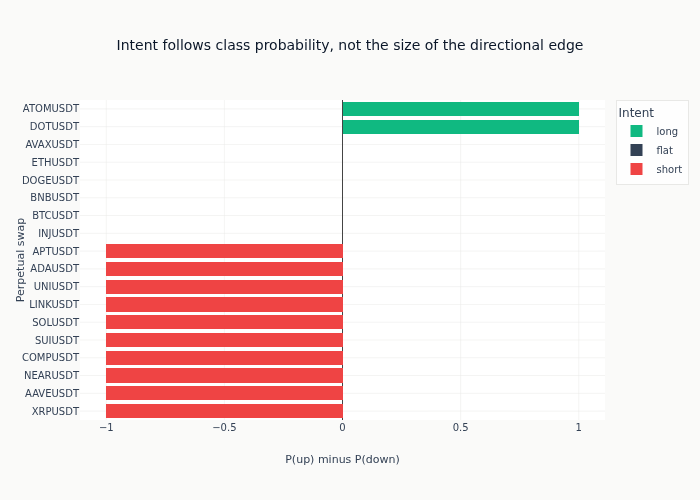

In [36]:
plot_predictions = predictions.with_columns(
    (pl.col("p_up") - pl.col("p_down")).alias("direction_edge")
).sort("direction_edge")
intent_colors = {
    "long": COLORS["positive"],
    "short": COLORS["negative"],
    "flat": COLORS["neutral"],
}
fig = go.Figure()
for intent in ["short", "flat", "long"]:
    subset = plot_predictions.filter(pl.col("intent") == intent)
    if len(subset) == 0:
        continue
    fig.add_bar(
        x=subset["direction_edge"].to_list(),
        y=subset["symbol"].to_list(),
        name=intent,
        orientation="h",
        marker_color=intent_colors[intent],
    )
fig.update_layout(
    title="Intent follows class probability, not the size of the directional edge",
    xaxis_title="P(up) minus P(down)",
    yaxis_title="Perpetual swap",
    barmode="stack",
    legend_title_text="Intent",
)
show_plotly_with_alt(
    fig,
    "Horizontal bar chart of the directional edge, P(up) minus P(down), for each perpetual in "
    "the live cross-section, sorted and coloured by the intent it produced. "
    + ", ".join(
        f"{intent}: {len(plot_predictions.filter(pl.col('intent') == intent))}"
        for intent in ["short", "flat", "long"]
    )
    + ".",
)

## 6. Trade: Alpaca Paper Crypto

Map intent to Alpaca paper crypto orders for the eleven USD-quoted spot
pairs. The unmatched eight perps are logged as signal-only. Alpaca trades
*spot* in *USD* whereas the strategy was researched on *perps* in *USDT*
with funding-rate carry, so the paper-execution leg is a wiring rehearsal
(order semantics under a real broker session), not a faithful PnL
reproduction of the funding strategy. Two frictions are deliberate:
spot/perp (no funding flow on Alpaca), and USD/USDT (paper accounts
auto-fund USD but not USDT, so USDT-pair orders fail with insufficient
balance until the operator manually funds USDT).

In [37]:
print("\n" + "=" * 70)
print("STEP 6: PAPER EXECUTION (ALPACA)")
print("=" * 70)


STEP 6: PAPER EXECUTION (ALPACA)


Classification distinguishes model inactivity, venue mismatch, disabled execution, and unsupported shorts.

In [38]:
def classify_crypto_intent(row: dict) -> dict:
    """Build the audit record and classify all non-submission outcomes."""
    symbol, intent = row["symbol"], row["intent"]
    record = {
        "symbol": symbol,
        "intent": intent,
        "p_up": row["p_up"],
        "p_down": row["p_down"],
        "p_flat": row["p_flat"],
        "ref_price": row["close"],
    }
    if intent == "flat":
        return record | {"status": "skipped_flat"}
    alpaca_pair = ALPACA_USD_PAIR.get(symbol)
    if alpaca_pair is None:
        return record | {
            "status": "signal_only",
            "reason": "no Alpaca USD-quoted spot listing",
        }
    record["alpaca_pair"] = alpaca_pair
    if intent == "short":
        record["status"] = "short_unsupported"
    elif not SUBMIT_PAPER_ORDERS:
        record["status"] = "dry_run"
    elif not HAS_ALPACA:
        record["status"] = "no_credentials"
    return record

Only an authorized long intent reaches the broker; every publication-default record returns earlier.

In [39]:
async def submit_crypto_intent(row: dict) -> dict:
    """Plan or submit one crypto intent."""
    record = classify_crypto_intent(row)
    if "status" in record:
        return record
    ref_price = float(record["ref_price"])
    quantity = round(NOTIONAL_PER_LEG_USD / ref_price, 6) if ref_price > 0 else 0.0
    try:
        order = await broker.submit_order_async(
            asset=record["alpaca_pair"],
            quantity=quantity,
            side=OrderSide.BUY,
        )
        record.update(
            status="submitted",
            qty=quantity,
            order_id=getattr(order, "id", None) or str(order),
        )
    except Exception as exc:
        record.update(status="submit_failed", error=repr(exc))
        logger.warning("Alpaca submit failed for %s: %s", record["symbol"], exc)
    return record

The venue session opens only when credentials and explicit paper-order authorization are both present.

In [40]:
async def submit_basket(intents: list[dict]) -> list[dict]:
    """Process the full prediction cross-section with a bounded broker session."""
    if broker is not None:
        await broker.connect()
    try:
        return [await submit_crypto_intent(row) for row in intents]
    finally:
        if broker is not None:
            await broker.disconnect()

In [41]:
intents = predictions.to_dicts()
exec_results = run_async(submit_basket(intents))
if not SUBMIT_PAPER_ORDERS:
    assert all(record["status"] != "submitted" for record in exec_results)

status_counts: dict[str, int] = {}
for r in exec_results:
    status_counts[r["status"]] = status_counts.get(r["status"], 0) + 1

print("\nExecution summary:")
for status, n in sorted(status_counts.items()):
    print(f"  {status:<22} {n}")

print("\nPer-symbol detail:")
for r in exec_results:
    extras = []
    if "alpaca_pair" in r:
        extras.append(r["alpaca_pair"])
    if "qty" in r:
        extras.append(f"qty={r['qty']}")
    if "order_id" in r:
        extras.append(f"order={str(r['order_id'])[:16]}")
    if "error" in r:
        extras.append(r["error"][:60])
    extra = " ".join(extras)
    print(f"  {r['symbol']:<10} {r['intent']:<6} p_up={r['p_up']:.2f} → {r['status']:<20} {extra}")


Execution summary:
  dry_run                1
  short_unsupported      6
  signal_only            5
  skipped_flat           6

Per-symbol detail:
  AAVEUSDT   short  p_up=0.00 → short_unsupported    AAVE/USD
  ADAUSDT    short  p_up=0.00 → short_unsupported    ADA/USD
  APTUSDT    short  p_up=0.00 → signal_only          
  ATOMUSDT   long   p_up=1.00 → signal_only          
  AVAXUSDT   flat   p_up=0.00 → skipped_flat         
  BNBUSDT    flat   p_up=0.00 → skipped_flat         
  BTCUSDT    flat   p_up=0.00 → skipped_flat         
  COMPUSDT   short  p_up=0.00 → signal_only          
  DOGEUSDT   flat   p_up=0.00 → skipped_flat         
  DOTUSDT    long   p_up=1.00 → dry_run              DOT/USD
  ETHUSDT    flat   p_up=0.00 → skipped_flat         
  INJUSDT    flat   p_up=0.00 → skipped_flat         
  LINKUSDT   short  p_up=0.00 → short_unsupported    LINK/USD
  NEARUSDT   short  p_up=0.00 → signal_only          
  SOLUSDT    short  p_up=0.00 → short_unsupported    SOL/USD
  SUI

The execution summary distinguishes flat intent, an absent
mapping, an unsupported spot short, an intentional dry run, and a missing
credential. Each status has a different operator response. Publication mode
should contain no `submitted` record because order submission is disabled.

## 7. Persist Run JSON

The run record is the per-cycle audit trail. It captures the model
fingerprint, the predict cross-section, and the execution disposition for
every symbol. Run JSONs are gitignored under the output directory and
accumulate as the deployment loop runs.

In [42]:
print("\n" + "=" * 70)
print("STEP 7: PERSIST RUN")
print("=" * 70)

run_ts = datetime.now(UTC)
run = {
    "run_ts_utc": run_ts.isoformat(),
    "case_study": "crypto_perps_funding",
    "model_metadata": metadata,
    "data_plane": {
        "venue": "OKX",
        "instruments_requested": CASE_STUDY_UNIVERSE,
        "instruments_fetched": available_symbols,
        "coverage": coverage,
        "minimum_coverage": MIN_OKX_LIVE_COVERAGE,
        "fetch_errors": [{"symbol": s, "error": e} for s, e in fetch_errors],
        "latest_bar_ts_utc": str(live_prices["timestamp"].max()),
        "candle_parser_audit": audit_frame.to_dicts(),
        "funding_parser_audit": funding_audit_frame.to_dicts(),
    },
    "execution_plane": {
        "venue": "Alpaca paper crypto",
        "credentials_present": HAS_ALPACA,
        "submit_enabled": SUBMIT_PAPER_ORDERS,
        "alpaca_supported_universe": list(ALPACA_USD_PAIR.keys()),
    },
    "predictions": predictions.to_dicts(),
    "execution": exec_results,
    "summary": {
        "n_symbols_predicted": len(predictions),
        "n_long": int((predictions["intent"] == "long").sum()),
        "n_short": int((predictions["intent"] == "short").sum()),
        "n_flat": int((predictions["intent"] == "flat").sum()),
        "status_counts": status_counts,
    },
}
run_path = RUNS_DIR / f"{run_ts.strftime('%Y%m%dT%H%M%SZ')}.json"
with open(run_path, "w") as f:
    json.dump(run, f, indent=2, default=str)
print(f"Run persisted: {display_path(run_path)}")


STEP 7: PERSIST RUN
Run persisted: 25_live_trading/output/crypto_funding_deployment/runs/20260909T012756Z.json


## Key Takeaways

1. **Two venues, two roles, two risks.** OKX provides the funding-rate
   signal that drives the strategy; Alpaca paper crypto provides the
   execution rehearsal. The notebook surfaces failures in either plane
   distinctly: a missing OKX response is a different operational event
   from a missing Alpaca pair.
2. **Research universes do not always match deployment universes.** The
   fixed teaching map routes eleven perps to Alpaca paper and records the
   remaining eight as signal-only. The OKX data plane separately records
   instruments retired by the live venue and stops if coverage falls below
   the declared floor. Both gaps are explicit deployment inputs.
3. **The deployment artefact is not the research artefact.** Same data,
   same labels, different feature subset (the thirteen the live pipeline
   can compute), different code path. Hyperparameters cross over from
   research to deployment; trained weights do not.
4. **Spot-vs-perp and USD-vs-USDT are measured caveats.** Alpaca paper
   trades spot crypto in USD; the case study trades USDT-quoted perpetual
   swaps with funding carry. Two real frictions: spot has no funding flow,
   and Alpaca paper accounts auto-fund USD but not USDT (USDT-pair orders
   fail with insufficient balance until manually funded). The paper
   execution exercises real broker-session mechanics under real
   credentials; it is not a faithful PnL reproduction of the funding
   strategy.
5. **Order submission is explicit opt-in.** The publication run leaves
   `SUBMIT_PAPER_ORDERS=False`, records dry-run dispositions, and never
   connects to Alpaca. Paper execution is a separate operator decision.

**Next**: see `08_pipeline_verification.ipynb` for systematic parity
testing across pipeline stages, and `10_safety_risk_demo.ipynb` for the
SafeBroker controls that would wrap this loop in a production deployment.